# Passive Mach-Zehnder Interferometer (MZI) -- Meep Baseline, $\Delta L$ Sweep, and Design Selection

This is the seventh "LEGO block" in the toolkit, and the first genuinely
**interferometric** one: two of `06_directional_coupler.ipynb`'s validated 50:50
couplers, joined by two arms of *different* optical path length $\Delta L$. Unlike a
Mach-Zehnder **modulator** (both arms the same length, interference created by an
index perturbation on one arm), this device is fully **passive**: both arms share
identical width and material, and the interference comes purely from a **geometric
path-length difference** $\Delta L$.

Like every earlier notebook, this one is an educational/validation record, not just a
script -- work through it step by step, and stop at the marked checkpoints to actually
look at the plots before continuing. **Do not use "Run All."**

**Runtime note**: this device's simulation cell is considerably longer than any other
`pic_toolkit` component's (two coupler stages plus a delay arm), and its cell also
grows TALLER as `delta_L_um` grows (the delay arm's bump needs more vertical room), so
each `simulate_baseline()` call is the slowest in the toolkit -- expect it to take a
while, especially in Section 10's sweep.
</cell id="bc82475e">


## 1. Physical objective and topology

Standard S-parameter numbering is used throughout: port 1 = `in_top`, port 2 =
`in_bot`, port 3 = `out_top`, port 4 = `out_bot`. Exciting port 1, $S_{31}$ and $S_{41}$
are the complex responses at `out_top`/`out_bot` -- their magnitudes squared give the
usual transmission spectra, and their **phase** is also recorded directly (unlike
`coupler.py`, which only measures power).

Since $\Delta\phi(\lambda) = \dfrac{2\pi n_\mathrm{eff}}{\lambda}\Delta L$, what
matters is the **optical path length difference along the waveguide centerline**, not
the raw device footprint. This notebook's arm geometry follows from that directly: both
arms extend from the same coupler port coordinates to the same far coordinates
regardless of $\Delta L$; the reference (top) arm is a plain straight run; the delay
(bottom) arm replaces that same span with a single smooth raised-cosine bump that
accumulates the extra centerline length, bulging away from the device centerline (see
`docs/simulation_settings_record.md` for why a single large bump is the lower-loss
choice over a serpentine of many small ones).


## 2. User parameters

Same units and material convention as every other component: lengths in
micrometers, silicon core / silicon dioxide cladding.

In [1]:
import inspect
import json

import numpy as np
import matplotlib.pyplot as plt
import gdsfactory as gf

from pic_toolkit.meep_sim import mzi
from pic_toolkit import viz, design_points, sweep as sweep_mod, style

style.apply_style()  # shared color palette + plot style for every notebook in this toolkit
%matplotlib inline

# ============================================================
# USER PARAMETERS
# ============================================================
params = dict(mzi.DEFAULT_PARAMS)
params


{'coupling_length_um': 13.848128928800111,
 'gap_um': 0.2,
 'wg_width_um': 0.5,
 'wg_height_um': 0.22,
 'core_index': 2.7,
 'clad_index': 1.44,
 'sbend_len_um': 6.0,
 'wide_sep_um': 2.0,
 'lead_len_um': 2.0,
 'n_seg': 24,
 'mon_size_um': 1.2,
 'margin_um': 0.7,
 'wl_min_um': 1.3,
 'wl_max_um': 1.4,
 'n_freq': 101,
 'resolution': 25,
 'dpml_um': 1.0,
 'bump_n_seg': 200,
 'delay_region_len_um': 50.0,
 'delta_L_um': 10.0,
 'dft_decay_tol': 0.001,
 'min_sim_time_factor': 2.0,
 'max_sim_time_factor': 4.0}

In [2]:
# The MZI's two coupler stages reuse 06_directional_coupler.ipynb's own validated
# 50:50 design point verbatim -- confirm the two notebooks haven't drifted apart
# before building anything on top of it.
coupler_design_point = design_points.load_design_point("../data/design_points/coupler.yaml")
assert params["coupling_length_um"] == coupler_design_point["parameters"]["coupling_length_um"], (
    "mzi.DEFAULT_PARAMS['coupling_length_um'] no longer matches the coupler's saved design point -- "
    "if 06_directional_coupler.ipynb was re-run and selected a different value, update mzi.py's "
    "DEFAULT_PARAMS to match it."
)
print("coupler design point coupling_length_um matches mzi.py's DEFAULT_PARAMS:",
      params["coupling_length_um"])


coupler design point coupling_length_um matches mzi.py's DEFAULT_PARAMS: 13.848128928800111


What each parameter means physically (see `docs/simulation_settings_record.md` for
the studies behind the non-obvious choices):

- **`coupling_length_um` / `gap_um` / `wg_width_um` / `wg_height_um` / `core_index` /
  `clad_index` / `sbend_len_um` / `wide_sep_um` / `lead_len_um` / `n_seg` /
  `mon_size_um` / `margin_um`** -- all reused **verbatim** from `coupler.py`'s own
  `DEFAULT_PARAMS` (`coupling_length_um` specifically from
  `data/design_points/coupler.yaml`, confirmed to match above). Both the splitter and
  combiner stage are built from this exact, already-validated 50:50 design.
  `wide_sep_um` is the coupler ports' own separation, and stays **unchanged** here --
  it is exactly the MZI's own `in_top`/`in_bot`/`out_top`/`out_bot` port separation.
- **`delay_region_len_um`** -- the straight x-span shared by BOTH arms, extending
  directly from each coupler stage's own ports. Fixed regardless of `delta_L_um` --
  only what happens *inside* this span differs between the two arms (a straight run
  on top, a single bump on the bottom).
- **`bump_n_seg`** -- thin `Block`s approximating the delay arm's single raised-cosine
  bump, finer than the coupler's own `n_seg=24` since this bump's offset can be an
  order of magnitude larger.
- **`delta_L_um`** -- the arm path-length difference itself: this notebook's central
  parameter. Fixed at a baseline value here (Sections 5-9); swept 5-15um in Section
  10. Realized as a single raised-cosine bump on the delay arm (see `solve_delay_arm`
  in Section 3) -- because the bump's amplitude grows with `delta_L_um`, the
  simulation cell's height grows with it too, unlike every other `pic_toolkit`
  component.
- **`wl_min_um` / `wl_max_um` / `n_freq`** -- O-band (1300-1400nm), matching every
  other component.
- **`resolution` / `dpml_um`** -- matches `coupler.py`/`racetrack.py`.
- **`dft_decay_tol` / `min_sim_time_factor` / `max_sim_time_factor`** -- FDTD
  run-length control. The minimum run time is computed from
  `min_sim_time_factor * core_index * cell_x` at simulation time (see
  `meep_sim.mzi._run_one_excitation`), not a fixed constant -- this device's cell is
  far longer than any other component's, and a fixed floor tuned for a short cell
  would be too short here.

## 3. Build geometry

Native `mp.Block` construction (below): both coupler stages, joined by the straight
reference arm and the delay arm's single raised-cosine bump.

In [3]:
# Solve, by bisection, the single bump amplitude that adds exactly delta_L_um of
# extra centerline length over delay_region_len_um.
print(inspect.getsource(mzi.solve_delay_arm))

def solve_delay_arm(delta_L_um: float, delay_region_len_um: float, max_search_amplitude_um: float = 500.0) -> float:
    """Solve, by bisection, the single bump amplitude whose raised-cosine arc
    length exceeds delay_region_len_um by exactly delta_L_um. Arc length grows
    monotonically with amplitude, so bisection within
    [0, max_search_amplitude_um] is well-posed; max_search_amplitude_um is
    just a generous search ceiling; the toolkit's biggest CURRENT default
    (delta_L_um=20, delay_region_len_um=30) only needs ~15.6um.

    delta_L_um <= 0 returns 0.0 -- the trivial case, a plain straight arm.
    """
    if delta_L_um <= 0:
        return 0.0

    target_total = delay_region_len_um + delta_L_um
    lo, hi = 0.0, max_search_amplitude_um
    if _raised_cosine_arc_length(hi, delay_region_len_um) < target_total:
        raise ValueError(
            f"Could not realize delta_L_um={delta_L_um} over delay_region_len_um={delay_region_len_um} "
            f"within max_search_

In [4]:
# Realize the solved amplitude as many small Blocks, each rotated to its own local
# tangent direction, so the delay arm's true width stays constant even at this
# bump's steep local slopes (unlike the coupler's own axis-aligned S-bend blocks,
# which only hold the y-extent constant -- fine there since that slope stays small).
print(inspect.getsource(mzi._build_delay_arm_blocks))

def _build_delay_arm_blocks(x_start, x_end, baseline_y, amplitude_um, width, material, n_seg):
    """The delay (long) arm: a single raised-cosine bump from baseline_y,
    bulging AWAY from the device centerline (y=0) by amplitude_um, and back to
    baseline_y -- so it can never cross into the reference arm on the other
    side of the centerline regardless of amplitude.

    Built as n_seg small Blocks, each ROTATED to align with the centerline's
    OWN local tangent direction at its midpoint (via mp.Block's e1/e2 basis
    vectors) -- NOT coupler.s_bend_blocks' AXIS-ALIGNED stacked Blocks. Axis-
    aligned stacking only holds the y-EXTENT of each segment constant, not the
    true width perpendicular to the local propagation direction; that's an
    excellent approximation for coupler.py's own S-bends (max slope dy/dx
    ~0.17, under 2% width error) but breaks down for this bump, whose slope
    approaches order 1 near its midpoint at large delta_L_um: confirmed the
    effectiv

In [5]:
# Two translated coupler stages (reusing coupler.build_geometry verbatim) plus
# the reference (straight) and delay (bump) arms, joined at identical endpoints
# regardless of delta_L_um.
print(inspect.getsource(mzi.build_geometry))

def build_geometry(params: dict) -> list:
    """Two coupler stages (splitter, combiner), each coupler.build_geometry's
    own validated 50:50 shape translated into place, joined by two arms
    extending directly from the coupler ports' own wide_sep_um separation: a
    plain straight reference arm (top) and a single raised-cosine bump delay
    arm (bottom, bulging away from the centerline) carrying the extra
    delta_L_um. Both arms share identical start/end coordinates regardless of
    delta_L_um -- only the path taken between them differs.
    """
    dom = _compute_domain(params)
    core = mp.Medium(index=params["core_index"])
    width = params["wg_width_um"]

    stage_blocks = coupler.build_geometry(params)
    left = [_translate_block(b, dom["x_c1_center"]) for b in stage_blocks]
    right = [_translate_block(b, dom["x_c2_center"]) for b in stage_blocks]

    wide_half = dom["wide_half"]
    x_arm_L, x_arm_R = dom["x_arm_L"], dom["x_arm_R"]

    arm_blocks = [
        # r

**GDSFactory layout.** The same device, traced as a gdsfactory `Component` (both
coupler S-bends and the delay arm's bump follow the exact same raised-cosine
centerline the native construction above uses) -- this is the layout view a real
tapeout would use.

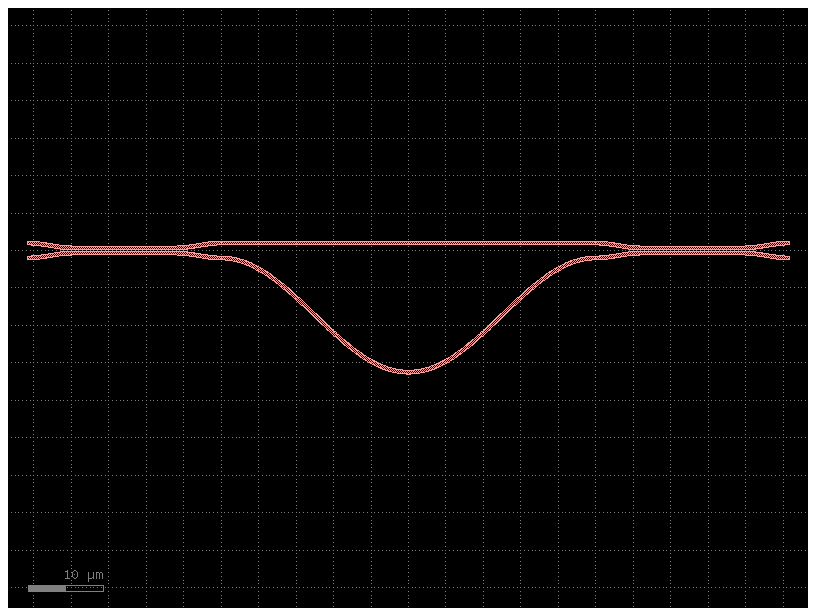

In [6]:
gf_component = mzi.build_gf_component(params)
fig = gf_component.plot()
plt.show()

## 4. Permittivity map

Built WITHOUT running any FDTD timestepping, from the gdsfactory-derived geometry
shown above.

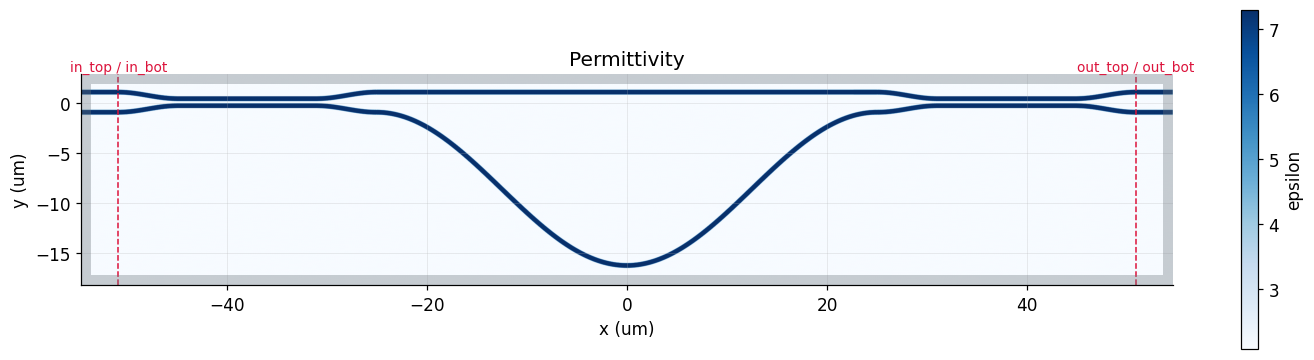

delta_L_um=10.0 -> bump amplitude=15.2388um (cell_y=21.14um)


In [7]:
# use_native_geometry=False -- the gdsfactory-derived geometry shown in Section 3,
# for a display view consistent with it. simulate_baseline() below still uses the
# native construction (see the comparison cell after this one for why).
fig, ax = plt.subplots(figsize=(16, 4))

perm_map = mzi.get_permittivity_map(params, use_native_geometry=False)
ports = mzi._ports(params)
viz.plot_permittivity(perm_map.eps, perm_map.extent_um, ax=ax, pml_um=params["dpml_um"], ports=[
    (ports["in_top"].x, 0, "in_top / in_bot", "v"),
    (ports["out_top"].x, 0, "out_top / out_bot", "v"),
])
plt.show()

dom = mzi._compute_domain(params)
print(f"delta_L_um={params['delta_L_um']} -> bump amplitude={dom['bend_amplitude_um']:.4f}um "
      f"(cell_y={dom['cell_y']:.2f}um)")


**Why `simulate_baseline()` still uses the native geometry.** The comparison below
(computing a second permittivity map -- this cell takes a while, like every full-cell
map in this notebook) shows a small, expected difference concentrated at the
coupler stages' S-bend edges: the native construction places axis-aligned `Block`s
(width measured in $y$ only), which `coupler.py`'s own docstring already notes is
accurate to within ~2% of the true perpendicular width at this device's gentle S-bend
slope. The gdsfactory path instead sweeps the cross-section perpendicular to the local
tangent -- the more physically exact representation, but a genuinely different
polygon at the sub-pixel level, not a construction error. Since every validated result
in this notebook (and `06_directional_coupler.ipynb`'s) was measured against the
native construction, `simulate_baseline()` keeps using it -- the gdsfactory path above
is for the layout view and this comparison only.

In [8]:
perm_map_native = mzi.get_permittivity_map(params, use_native_geometry=True)

diff = np.abs(perm_map_native.eps - perm_map.eps)
frac_differing = (diff > 0.01).sum() / diff.size
print(f"max |native - gds| eps difference:  {diff.max():.3f}")
print(f"mean |native - gds| eps difference: {diff.mean():.4f}")
print(f"fraction of pixels differing by >0.01: {frac_differing:.2%}  "
      f"(expected -- concentrated at the coupler S-bend edges, see markdown above)")


max |native - gds| eps difference:  3.457
mean |native - gds| eps difference: 0.0028
fraction of pixels differing by >0.01: 1.18%  (expected -- concentrated at the coupler S-bend edges, see markdown above)


> **STOP -- INSPECT THE PERMITTIVITY MAP BEFORE RUNNING FDTD.**
>
> Confirm: both coupler stages look identical to `06_directional_coupler.ipynb`'s
> validated geometry (S-bend down to a tight coupling gap, straight coupling run,
> S-bend back out); the top (reference) arm is a plain straight run; the bottom (delay)
> arm shows a single smooth bump bulging away from the centerline; and the bump's peak
> stays clear of the PML (it was sized in `_compute_domain` specifically to do so).

## 5. Baseline FDTD simulation

$\lambda = 1300$-$1400$nm, $\Delta L$ fixed at `params["delta_L_um"]`.

In [9]:
# Full 4-port characterization: excites in_top and in_bot independently, recording
# COMPLEX mode-coefficient ratios (magnitude AND phase) end to end -- this is what
# makes the interference pattern in Section 7 possible.
result = mzi.simulate_baseline(params)
print(f"{len(result.wavelengths_um)} wavelength points, "
      f"{result.wavelengths_um.min():.4f}-{result.wavelengths_um.max():.4f} um")


101 wavelength points, 1.3017-1.4020 um


## 6. Electromagnetic field visualization -- polarization convention

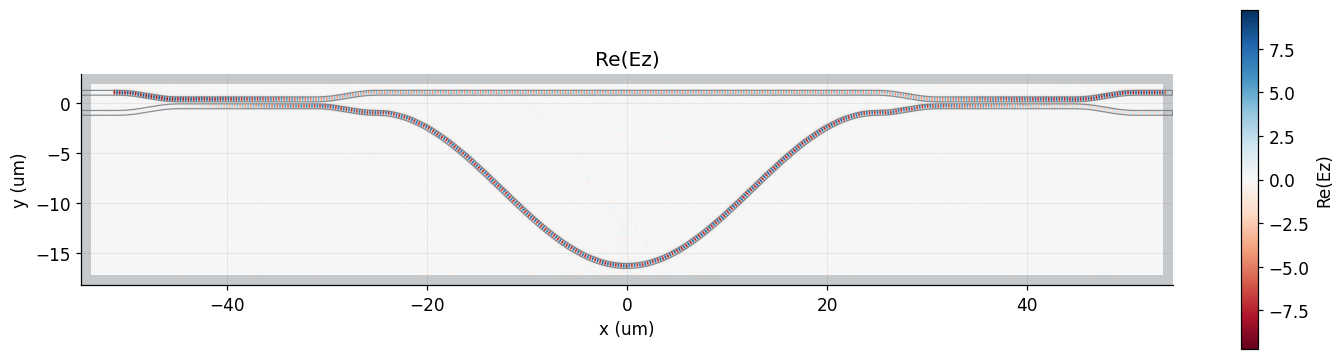

In [10]:
# Plot whichever field component actually dominates for this device's mode.
fs = result.field_snapshot
fig, ax = plt.subplots(figsize=(16, 4))
viz.plot_field(fs.field, fs.eps, fs.extent_um, component=fs.component, ax=ax, pml_um=params["dpml_um"])
plt.show()


> **STOP -- INSPECT THE ELECTROMAGNETIC FIELD BEFORE CONTINUING.**
>
> The field should show power entering at `in_top`, splitting at the first coupler,
> traveling down both arms (visibly out of phase with each other by the time they
> reach the second coupler, since one arm is longer), and recombining at the second
> coupler into `out_top`/`out_bot`.

## 7. Transmission and phase spectra

$|S_{31}|^2$, $|S_{41}|^2$, and their phase, from exciting port 1 (`in_top`).

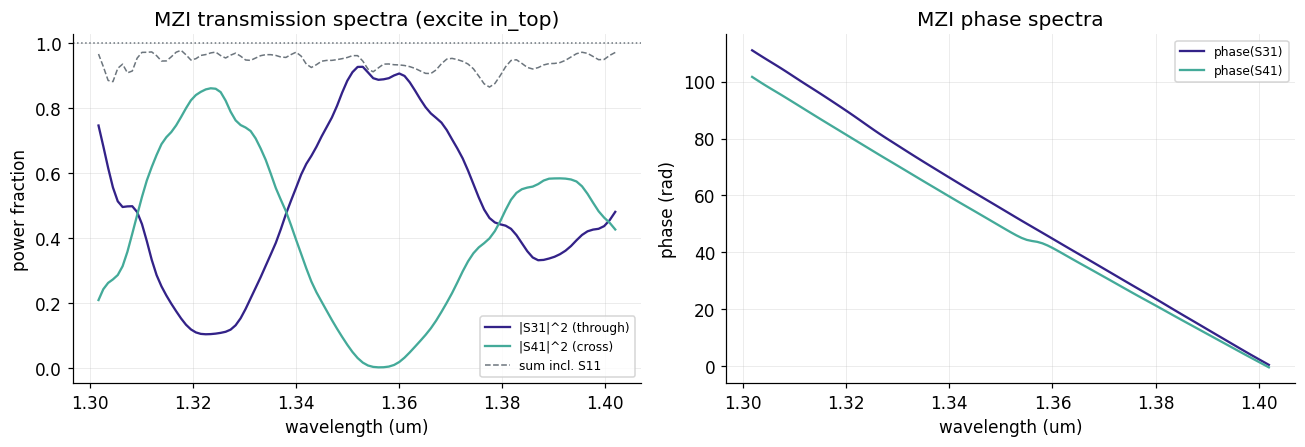

|S31|^2+|S41|^2+|S11|^2 range [0.8649, 0.9781] (should be close to 1)


In [11]:
# Through (S31) and cross (S41) power, plus a "sum incl. S11" dashed reference line --
# should sit close to 1.0 (a passive device can't create or destroy much power).
fig, (ax_mag, ax_phase) = plt.subplots(1, 2, figsize=(12, 4.2))

ax_mag.plot(result.wavelengths_um, np.abs(result.S31) ** 2, color=style.COLOR_CYCLE[0], label="|S31|^2 (through)")
ax_mag.plot(result.wavelengths_um, np.abs(result.S41) ** 2, color=style.COLOR_CYCLE[2], label="|S41|^2 (cross)")
ax_mag.plot(result.wavelengths_um, np.abs(result.S31) ** 2 + np.abs(result.S41) ** 2 + np.abs(result.S11) ** 2,
            "--", color=style.COLOR_REFERENCE, lw=1, label="sum incl. S11")
ax_mag.axhline(1.0, color=style.COLOR_REFERENCE, ls=":", lw=1)
ax_mag.set_xlabel("wavelength (um)")
ax_mag.set_ylabel("power fraction")
ax_mag.set_title("MZI transmission spectra (excite in_top)")
ax_mag.legend(fontsize=8)

ax_phase.plot(result.wavelengths_um, np.unwrap(np.angle(result.S31)), color=style.COLOR_CYCLE[0], label="phase(S31)")
ax_phase.plot(result.wavelengths_um, np.unwrap(np.angle(result.S41)), color=style.COLOR_CYCLE[2], label="phase(S41)")
ax_phase.set_xlabel("wavelength (um)")
ax_phase.set_ylabel("phase (rad)")
ax_phase.set_title("MZI phase spectra")
ax_phase.legend(fontsize=8)

fig.tight_layout()
plt.show()

# Energy-conservation sanity check, printed alongside the plot (Section 8 makes this
# an actual pass/fail assertion; this is just a quick numeric look first).
total = np.abs(result.S31) ** 2 + np.abs(result.S41) ** 2 + np.abs(result.S11) ** 2
print(f"|S31|^2+|S41|^2+|S11|^2 range [{total.min():.4f}, {total.max():.4f}] (should be close to 1)")


## 8. Physics sanity checks

`ENERGY_TOL`, `MAX_EXPECTED_LOSS`, and `RECIPROCITY_TOL` below are looser than a
single `coupler.py` stage's own budget -- this device chains TWO coupler stages plus
a delay-arm bump in series, so a somewhat larger accumulated loss and energy-budget
residual is expected, growing with `delta_L_um` (measured directly: ~3.9% at this
baseline `delta_L_um`, up to ~6.7% at the larger value Section 11 later selects; see
`docs/simulation_settings_record.md` for the full picture). `PASSIVITY_TOL` stays
tight: a passivity violation here would mean an actual bug, not just accumulated
loss.

In [12]:
# Run the 4-port composite validator (energy conservation, top/bottom-excitation
# reciprocity, passivity) and hard-stop (assert) rather than continuing with an
# unvalidated result.
ENERGY_TOL = 0.08  # see docs/simulation_settings_record.md -- this device's long simulation
                   # cell (two coupler stages + delay arm bump) carries an energy-budget
                   # residual that grows with delta_L_um (measured: ~3.9% at delta_L_um=10,
                   # ~6.7% at the larger delta_L_um Section 11 selects) -- set with real
                   # margin above the largest value measured across this notebook's range,
                   # matching MAX_EXPECTED_LOSS itself rather than a tighter, untested guess.
RECIPROCITY_TOL = 0.05
PASSIVITY_TOL = 0.01
MAX_EXPECTED_LOSS = 0.08  # see markdown above -- two coupler stages + delay arm bump in series

validation = mzi.run_all_checks(
    result,
    energy_tol=ENERGY_TOL,
    reciprocity_tol=RECIPROCITY_TOL,
    passivity_tol=PASSIVITY_TOL,
    max_expected_loss=MAX_EXPECTED_LOSS,
)

print(json.dumps(validation, indent=2))
assert validation["passed"], "Baseline failed sanity checks -- do not save or use this result."
print("\nBaseline validated.")


{
  "energy_conservation": {
    "max_deviation_port1": 0.050268044069512574,
    "max_deviation_port2": 0.0010534462605391592,
    "max_deviation": 0.050268044069512574,
    "max_expected_loss": 0.08,
    "tolerance": 0.08,
    "passed": true
  },
  "reciprocity": {
    "max_diff_input_leak": 0.024122318927651654,
    "max_diff": 0.024122318927651654,
    "tolerance": 0.05,
    "passed": true
  },
  "passivity": {
    "max_power_fraction": 0.9645017443754985,
    "tolerance": 0.01,
    "passed": true
  },
  "passed": true
}

Baseline validated.


## 9. Save baseline artifact

In [13]:
# Standard .npz (numeric arrays) + .json (metadata) artifact pair, same convention
# as every other component -- this is the raw, validated baseline, independent of
# any later delta_L_um sweep/selection.
artifact_stem = "../data/sparams/mzi/baseline/mzi_baseline"

metadata = {
    "component": "mzi",
    "geometry_params": {
        k: result.sim_params[k] for k in
        ["coupling_length_um", "gap_um", "wg_width_um", "wg_height_um", "sbend_len_um", "wide_sep_um",
         "lead_len_um", "n_seg", "mon_size_um", "bump_n_seg",
         "delay_region_len_um", "delta_L_um"]
    },
    "material_params": {k: result.sim_params[k] for k in ["core_index", "clad_index"]},
    "polarization": "TE (Ez out-of-plane, per project convention)",
    "meep_resolution": result.sim_params["resolution"],
    "simulation_params": {
        k: result.sim_params[k] for k in
        ["wl_min_um", "wl_max_um", "n_freq", "dpml_um", "margin_um", "dft_decay_tol",
         "min_sim_time_factor", "max_sim_time_factor"]
    },
    "meep_version": result.sim_params["meep_version"],
    "python_version": result.sim_params["python_version"],
    "creation_date": result.sim_params["creation_date"],
    "validation": validation,
}

mzi.save_artifact(artifact_stem, result, metadata)
print(f"Saved artifact: {artifact_stem}.npz / .json")


Saved artifact: ../data/sparams/mzi/baseline/mzi_baseline.npz / .json


---

## 10. Free spectral range vs. arm-length difference

A passive MZI with unequal arms interferes constructively or destructively as
wavelength changes. The wavelength spacing between successive transmission
maxima -- the **free spectral range (FSR)** -- is set by the *group* index
$n_g$, not the phase index $n_{eff}$:

$$\mathrm{FSR} \approx \frac{\lambda^2}{n_g \, \Delta L}$$

This section simulates six values of $\Delta L$, measures FSR directly from
each spectrum, and fits the formula above to extract $n_g$. A 100nm analysis
band can only resolve fringes with FSR below about 100nm -- for the smallest
$\Delta L$ values FSR exceeds the band and is reported as `NaN`. That is a
band-width limit, not a bug; see `docs/simulation_settings_record.md` for the
fringe-detection method.

**One-time exception to "Do not use Run All":** the cell below is scheduled
to run unattended overnight (six repeats of the full baseline simulation) --
run it start to finish rather than stopping at checkpoints.

> **STOP -- this is the slowest cell in the notebook.** Confirm Section 8's
> baseline passed cleanly first; the cell below repeats that same simulation
> 6 times at different `delta_L_um` values.

In [14]:
SWEEP_CHECK_KWARGS = dict(energy_tol=0.05, reciprocity_tol=0.08, passivity_tol=0.03, max_expected_loss=0.12)

# Six evenly-spaced delta_L values -- enough points to fit the FSR formula's one
# free parameter (n_g) with margin, while keeping the total sweep time bounded.
DELTA_L_SWEEP_UM = [2.5, 5.0, 7.5, 10.0, 12.5, 15.0]


def _local_maxima_indices(y, min_prominence_fraction=0.1):
    """Local-maximum indices (interior points only), keeping only peaks whose
    PROMINENCE (height above the adjacent valleys) exceeds `min_prominence_fraction`
    of the spectrum's own dynamic range -- filters out FDTD numerical noise so a
    single broad fringe isn't miscounted as two. See docs/simulation_settings_record.md."""
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(y, prominence=min_prominence_fraction * (np.max(y) - np.min(y)))
    return peaks


def fringe_metrics(wavelengths_um, power, wl0_um):
    """FSR = mean spacing between successive |S41|^2 fringe maxima (NaN if fewer
    than 2 are found -- FSR exceeds the analyzed band). extinction_db = 10*log10
    of the spectrum's max/min power ratio. peak_near_center_um = the detected
    fringe closest to the band-center wavelength wl0_um."""
    peaks = _local_maxima_indices(power)
    if len(peaks) >= 2:
        fsr_um = float(np.mean(np.diff(np.sort(wavelengths_um[peaks]))))
    else:
        fsr_um = float("nan")
    extinction_db = float(10 * np.log10(np.max(power) / max(np.min(power), 1e-12)))
    if len(peaks) >= 1:
        peak_wls = wavelengths_um[peaks]
        peak_near_center_um = float(peak_wls[np.argmin(np.abs(peak_wls - wl0_um))])
    else:
        peak_near_center_um = float("nan")
    return dict(fsr_um=fsr_um, extinction_db=extinction_db, peak_near_center_um=peak_near_center_um,
                n_peaks=int(len(peaks)))


WL0_UM = (params["wl_min_um"] + params["wl_max_um"]) / 2  # band-center reference wavelength

# One simulate_baseline() + validate + fringe-analysis + save per swept delta_L_um --
# each point gets its own artifact so any individual point can be reloaded later.
sweep_rows = []
for i, dL in enumerate(DELTA_L_SWEEP_UM, start=1):
    print(f"[{i}/{len(DELTA_L_SWEEP_UM)}] running mzi (delta_L_um={dL}) ...", flush=True)
    run_params = dict(params, delta_L_um=dL)
    r = mzi.simulate_baseline(run_params)
    v = mzi.run_all_checks(r, **SWEEP_CHECK_KWARGS)
    fm = fringe_metrics(r.wavelengths_um, np.abs(r.S41) ** 2, WL0_UM)
    stem = f"../data/sparams/mzi/sweep/mzi_deltaL{dL}"
    mzi.save_artifact(stem, r, {
        "component": "mzi", "delta_L_um": dL, "validation": v, "fringe_metrics": fm,
        "meep_version": r.sim_params["meep_version"], "creation_date": r.sim_params["creation_date"],
    })
    sweep_rows.append({"delta_L_um": dL, "artifact_path": stem, "validation_passed": v["passed"], **fm})

n_passed = sum(row["validation_passed"] for row in sweep_rows)
print(f"delta_L sweep: {n_passed}/{len(sweep_rows)} points within the (loose) sweep tolerance")

manifest_path = "../data/sparams/mzi/sweep/manifest.csv"
sweep_mod.save_manifest(sweep_rows, manifest_path)
print(f"Saved manifest to {manifest_path}")

[1/6] running mzi (delta_L_um=2.5) ...


[2/6] running mzi (delta_L_um=5.0) ...


[3/6] running mzi (delta_L_um=7.5) ...


[4/6] running mzi (delta_L_um=10.0) ...


[5/6] running mzi (delta_L_um=12.5) ...


[6/6] running mzi (delta_L_um=15.0) ...


delta_L sweep: 6/6 points within the (loose) sweep tolerance
Saved manifest to ../data/sparams/mzi/sweep/manifest.csv


### Result: FSR vs. $\Delta L$, and per-$\Delta L$ transmission spectra

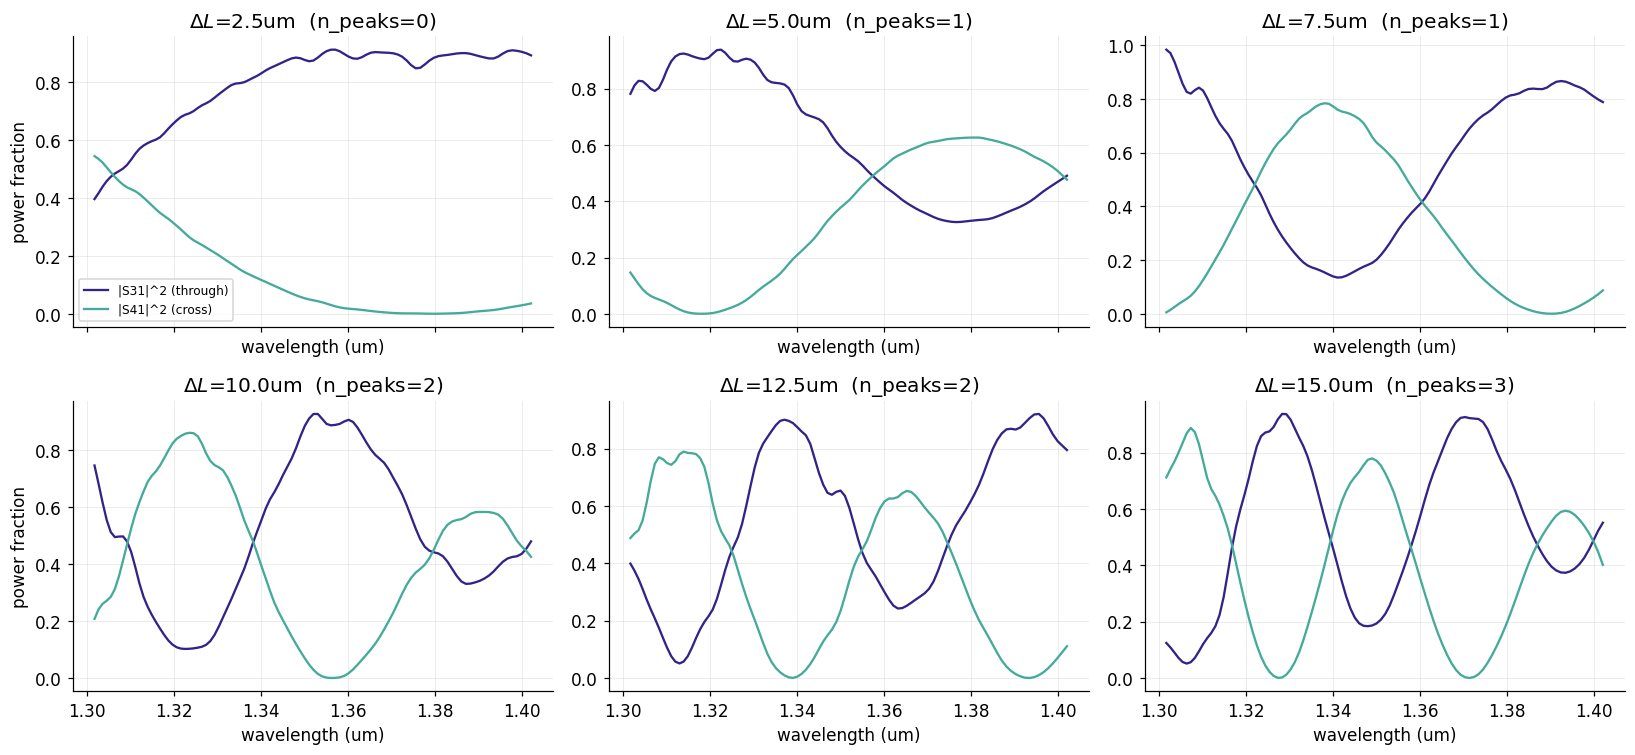

In [15]:
# Reload each swept point from disk (not kept in memory during the loop above) --
# same pattern 06_directional_coupler.ipynb's own sweep section uses.
loaded_sweep = [mzi.load_artifact(row["artifact_path"]) for row in sweep_rows]

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for ax, row, art in zip(axes.flat, sweep_rows, loaded_sweep):
    ax.plot(art.wavelengths_um, np.abs(art.S31) ** 2, color=style.COLOR_CYCLE[0], label="|S31|^2 (through)")
    ax.plot(art.wavelengths_um, np.abs(art.S41) ** 2, color=style.COLOR_CYCLE[2], label="|S41|^2 (cross)")
    ax.set_title(rf"$\Delta L$={row['delta_L_um']}um  (n_peaks={row['n_peaks']})")
    ax.set_xlabel("wavelength (um)")
axes[0, 0].set_ylabel("power fraction")
axes[1, 0].set_ylabel("power fraction")
axes[0, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

FSR measurable at 3/6 swept points (the rest exceed the 100nm analyzed band).
Fitted group index: n_g = 2.763 +/- 0.052


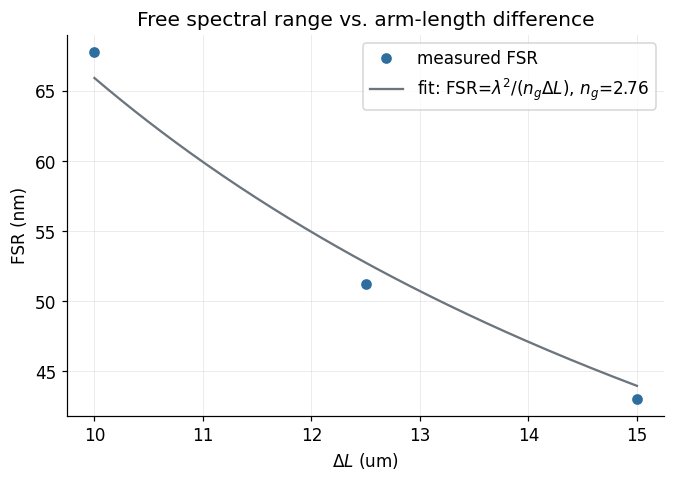

In [16]:
from scipy.optimize import curve_fit

dLs = np.array([row["delta_L_um"] for row in sweep_rows])
fsr_nm = np.array([row["fsr_um"] for row in sweep_rows]) * 1000.0  # um -> nm

def fsr_model_nm(delta_L_um, n_g):
    # FSR [nm] = (lambda0 [nm])^2 / (n_g * delta_L [um]), converted back to nm.
    return (WL0_UM * 1000.0) ** 2 / (n_g * delta_L_um) / 1000.0

finite = np.isfinite(fsr_nm)
n_fit_points = int(finite.sum())
if n_fit_points >= 2:
    popt, pcov = curve_fit(fsr_model_nm, dLs[finite], fsr_nm[finite], p0=[3.5])
    N_G_FDTD_FIT, n_g_fit_stderr = float(popt[0]), float(np.sqrt(pcov[0, 0]))
    print(f"FSR measurable at {n_fit_points}/{len(dLs)} swept points "
          f"(the rest exceed the 100nm analyzed band).")
    print(f"Fitted group index: n_g = {N_G_FDTD_FIT:.3f} +/- {n_g_fit_stderr:.3f}")
else:
    N_G_FDTD_FIT, n_g_fit_stderr = float("nan"), float("nan")
    print(f"Only {n_fit_points}/{len(dLs)} points show a measurable FSR -- not enough to fit.")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dLs[finite], fsr_nm[finite], "o", color=style.COLOR_STEEL, label="measured FSR")
ax.plot(dLs[~finite], np.zeros(int((~finite).sum())), "x", color=style.COLOR_REFERENCE,
        label="FSR > 100nm band (not resolved)")
if n_fit_points >= 2:
    dL_curve = np.linspace(dLs[finite].min(), dLs[finite].max(), 200)
    ax.plot(dL_curve, fsr_model_nm(dL_curve, N_G_FDTD_FIT), color=style.COLOR_REFERENCE,
            label=rf"fit: FSR=$\lambda^2/(n_g\Delta L)$, $n_g$={N_G_FDTD_FIT:.2f}")
ax.set_xlabel(r"$\Delta L$ (um)")
ax.set_ylabel("FSR (nm)")
ax.set_title("Free spectral range vs. arm-length difference")
ax.legend()
plt.show()

### $n_{eff}$ vs. $n_g$: why FSR measures the group index

Two different refractive indices describe a guided mode:

- **Phase index** $n_{eff}(\lambda)$ sets how fast *phase* accumulates along
  the waveguide: $\phi = 2\pi n_{eff}(\lambda) \Delta L / \lambda$. This is
  what determines constructive vs. destructive interference at a given
  wavelength.
- **Group index** $n_g(\lambda)$ sets how fast the *envelope* -- and
  therefore information -- travels, and is what actually sets the fringe
  spacing:

$$n_g(\lambda) = n_{eff}(\lambda) - \lambda \frac{d n_{eff}}{d \lambda}$$

`mzi.compute_arm_dispersion()` solves for $n_{eff}(\lambda)$ at several
wavelengths with a cheap MPB eigenmode solve (no FDTD timestepping -- seconds,
not minutes) on the same arm cross-section the FDTD runs above use. The
formula above is then evaluated numerically from that dispersion curve. MPB
also reports each mode's group velocity directly, giving a second,
independent estimate of $n_g$ to cross-check against.

The two `n_g` values below need not match exactly: the dispersion calculation characterizes a straight, unbent segment of the arm waveguide, while the FSR fit reflects the full round-trip path through both coupler S-bends and the delay arm's own curve -- a difference of a few percent between them is expected, not an error.

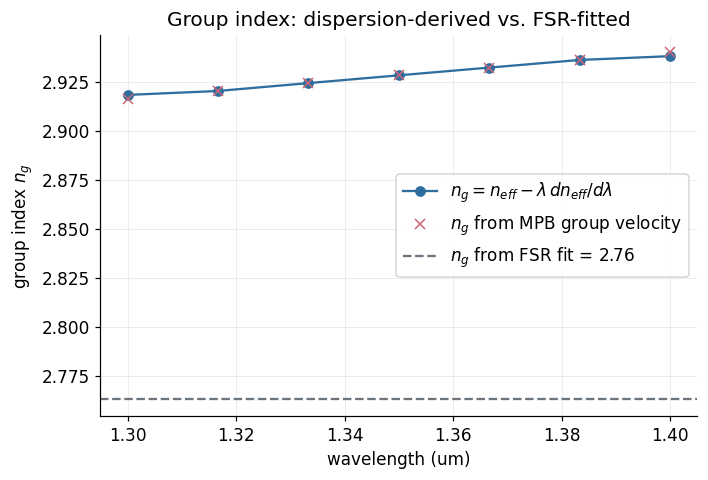

At 1.350um:
  n_eff (phase index)              = 2.4085
  n_g, finite-difference dispersion = 2.9283
  n_g, MPB group velocity           = 2.9283
  n_g, FDTD fringe-spacing fit      = 2.7633


In [17]:
wl_samples = np.linspace(params["wl_min_um"], params["wl_max_um"], 7)
dispersion = mzi.compute_arm_dispersion(params, wl_samples)

# Finite-difference group index from the n_eff(wavelength) curve above.
n_g_fd = dispersion["n_eff"] - dispersion["wavelengths_um"] * np.gradient(
    dispersion["n_eff"], dispersion["wavelengths_um"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dispersion["wavelengths_um"], n_g_fd, "o-", color=style.COLOR_STEEL,
        label=r"$n_g = n_{eff} - \lambda\, dn_{eff}/d\lambda$")
ax.plot(dispersion["wavelengths_um"], dispersion["n_g_direct"], "x", color=style.COLOR_ROSE,
        label="$n_g$ from MPB group velocity")
if np.isfinite(N_G_FDTD_FIT):
    ax.axhline(N_G_FDTD_FIT, color=style.COLOR_REFERENCE, ls="--",
               label=f"$n_g$ from FSR fit = {N_G_FDTD_FIT:.2f}")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("group index $n_g$")
ax.set_title("Group index: dispersion-derived vs. FSR-fitted")
ax.legend()
plt.show()

i0 = len(wl_samples) // 2
print(f"At {dispersion['wavelengths_um'][i0]:.3f}um:")
print(f"  n_eff (phase index)              = {dispersion['n_eff'][i0]:.4f}")
print(f"  n_g, finite-difference dispersion = {n_g_fd[i0]:.4f}")
print(f"  n_g, MPB group velocity           = {dispersion['n_g_direct'][i0]:.4f}")
if np.isfinite(N_G_FDTD_FIT):
    print(f"  n_g, FDTD fringe-spacing fit      = {N_G_FDTD_FIT:.4f}")

## 11. Design selection

**No automatic optimizer**, same philosophy as `05_racetrack_resonator.ipynb`/
`06_directional_coupler.ipynb`'s own Section 11 -- but here the goal (clearly resolved
interference, not a single ambiguous partial fringe) is explicit enough to state
directly: among the validated sweep points with at least 2 detected fringe maxima
in-band (so FSR is actually measurable), pick the one with the highest extinction
ratio. If none qualify, fall back to the highest-extinction point overall.

In [18]:
# Among sweep points that both passed validation and showed a genuinely measurable
# FSR (>=2 fringes in-band), pick the one with the deepest extinction.
candidates = [row for row in sweep_rows if row["validation_passed"] and row["n_peaks"] >= 2]
if not candidates:
    candidates = sweep_rows
best_row = max(candidates, key=lambda r: r["extinction_db"])
SELECTED_DELTA_L_UM = best_row["delta_L_um"]
print(f"Selected delta_L_um = {SELECTED_DELTA_L_UM} "
      f"(FSR={best_row['fsr_um']:.4f}um, extinction={best_row['extinction_db']:.2f}dB, "
      f"n_peaks={best_row['n_peaks']})")


Selected delta_L_um = 12.5 (FSR=0.0513um, extinction=33.97dB, n_peaks=2)


**Re-validate at the selected point.** The sweep above used loosened tolerances
(`SWEEP_CHECK_KWARGS`) -- before saving a design point, re-run `simulate_baseline` at
`SELECTED_DELTA_L_UM` and validate it against the SAME strict tolerances Section 8
used for the baseline, same discipline as every earlier component's design-selection
section.

In [19]:
# Re-run at the exact selected delta_L_um and re-validate against the strict
# Section-8 tolerances (not the loosened sweep tolerances) before saving anything.
selected_params = dict(params, delta_L_um=SELECTED_DELTA_L_UM)
selected_result = mzi.simulate_baseline(selected_params)
selected_validation = mzi.run_all_checks(
    selected_result,
    energy_tol=ENERGY_TOL, reciprocity_tol=RECIPROCITY_TOL,
    passivity_tol=PASSIVITY_TOL, max_expected_loss=MAX_EXPECTED_LOSS,
)
print(json.dumps(selected_validation, indent=2))
assert selected_validation["passed"], "Selected design point failed strict sanity checks -- do not save it."

selected_fringe = fringe_metrics(selected_result.wavelengths_um, np.abs(selected_result.S41) ** 2, WL0_UM)
print(f"\nAt selected delta_L_um={SELECTED_DELTA_L_UM}: {selected_fringe}")


{
  "energy_conservation": {
    "max_deviation_port1": 0.07397238148483676,
    "max_deviation_port2": 0.0,
    "max_deviation": 0.07397238148483676,
    "max_expected_loss": 0.08,
    "tolerance": 0.08,
    "passed": true
  },
  "reciprocity": {
    "max_diff_input_leak": 0.0027550868478446425,
    "max_diff": 0.0027550868478446425,
    "tolerance": 0.05,
    "passed": true
  },
  "passivity": {
    "max_power_fraction": 0.9693185692100867,
    "tolerance": 0.01,
    "passed": true
  },
  "passed": true
}

At selected delta_L_um=12.5: {'fsr_um': 0.05125073429700988, 'extinction_db': 33.97151715026488, 'peak_near_center_um': 1.3651896096680094, 'n_peaks': 2}


## 12. Save S-parameter dataset

In [20]:
# Save the re-validated artifact, then the design point (single source of truth --
# anything downstream reads geometry parameters and the source artifact from here).
SELECTED_ARTIFACT = "data/sparams/mzi/selected/mzi_selected"
mzi.save_artifact(f"../{SELECTED_ARTIFACT}", selected_result, {
    "component": "mzi",
    "geometry_params": {
        k: selected_result.sim_params[k] for k in
        ["coupling_length_um", "gap_um", "wg_width_um", "wg_height_um", "sbend_len_um", "wide_sep_um",
         "lead_len_um", "n_seg", "mon_size_um", "bump_n_seg",
         "delay_region_len_um", "delta_L_um"]
    },
    "material_params": {k: selected_result.sim_params[k] for k in ["core_index", "clad_index"]},
    "meep_resolution": selected_result.sim_params["resolution"],
    "meep_version": selected_result.sim_params["meep_version"],
    "creation_date": selected_result.sim_params["creation_date"],
    "validation": selected_validation,
    "fringe_metrics": selected_fringe,
})
print(f"Saved re-validated artifact: {SELECTED_ARTIFACT}.npz / .json")

design_point_path = "../data/design_points/mzi.yaml"
design_points.save_design_point(design_point_path, {
    "component": "mzi",
    "parameters": {
        "coupling_length_um": params["coupling_length_um"],
        "gap_um": params["gap_um"],
        "wg_width_um": params["wg_width_um"],
        "wg_height_um": params["wg_height_um"],
        "core_index": params["core_index"],
        "clad_index": params["clad_index"],
        "sbend_len_um": params["sbend_len_um"],
        "wide_sep_um": params["wide_sep_um"],
        "delay_region_len_um": params["delay_region_len_um"],
        "bump_n_seg": params["bump_n_seg"],
        "delta_L_um": SELECTED_DELTA_L_UM,
    },
    "source_artifact": SELECTED_ARTIFACT,
    "provenance": {
        "method": "sweep_selection_max_extinction_with_resolved_fringes",
        "date": selected_result.sim_params["creation_date"],
        "meep_version": selected_result.sim_params["meep_version"],
    },
    "validation": selected_validation,
    "rationale": (
        f"Selected from the Section-10 delta_L sweep ({DELTA_L_SWEEP_UM}) as the point with the "
        f"highest extinction ratio among those showing at least 2 resolved fringe maxima in-band "
        f"(so FSR is actually measurable, not just a single ambiguous partial fringe). "
        f"Re-simulated and re-validated at this exact delta_L_um against the strict Section-8 "
        f"tolerances (not the loosened sweep tolerances) before saving. Edit this rationale "
        f"directly if a different point is preferred."
    ),
})
print(f"Saved design point: {design_point_path}")


Saved re-validated artifact: data/sparams/mzi/selected/mzi_selected.npz / .json
Saved design point: ../data/design_points/mzi.yaml


## 13. MZI SAX model

`src/pic_toolkit/models/mzi.py` is the reusable LEGO brick built from the design point
saved above. **It is not exercised in this notebook** -- this notebook already imports
meep, and the whole point of the SAX model is that it must work in a process that
never has -- so it should be verified separately, in a clean, meep-free process (same
approach every other component uses). Unlike `models/coupler.py`, this model returns
genuine complex S-parameters directly (no `sqrt(power)` zero-phase simplification
needed), since `meep_sim.mzi.simulate_baseline` records real phase.

In [21]:
# Print the reusable SAX model this design point feeds -- verified separately in a
# clean, meep-free process (see the markdown above).
with open("../src/pic_toolkit/models/mzi.py") as f:
    print(f.read())


"""SAX-compatible component model for the passive Mach-Zehnder interferometer.

Architectural rule: this file NEVER imports meep, and NEVER launches an FDTD
simulation -- same rule as models/coupler.py, models/racetrack.py, etc. It
reads the cached, validated artifact that notebooks/07_mzi.ipynb already
produced and selected, via the design point that names it.

Unlike models/coupler.py (which can only return sqrt(power) -- zero-phase --
S-parameters, an explicitly documented simplification), this model returns
genuine COMPLEX S-parameters directly, since meep_sim.mzi.simulate_baseline
records real phase, not just power. This is what makes a standalone SAX
composition of two coupler stages + an analytic arm phase term unnecessary:
the whole interferometric response is already captured in one cached
artifact.

Same "duplication over a shared helper" convention models/coupler.py already
established relative to pic_toolkit.sparams (hardcoded to a 2x2 s_matrix,
can't represent this 4-port 

---

## 14. Summary

Baseline validated (energy conservation, top/bottom reciprocity, and passivity all
checked honestly against this device's own 4-port complex physics), a six-point
$\Delta L$ sweep performed with the free spectral range fit to extract the group
index (cross-checked against an independent dispersion calculation), and a design
point selected, re-simulated, and re-validated against the strict baseline tolerances
before saving. The MZI SAX model can now be loaded in any meep-free process via
`from pic_toolkit.models.mzi import mzi`, exactly like every other component -- and
unlike `models/coupler.py`, with genuine phase, closing the gap that module's own
docstring flagged.

This also closes the prerequisite chain `circuits/README.md` names explicitly
("...once a directional coupler component exists (needed for an MZI)..."). A
`circuits/`-level SAX composition (e.g. wiring independently-simulated coupler and
phase-shifter models together, rather than this notebook's single full-wave device) is
a natural next step, but out of scope here.